In [1]:
# ── Install dependencies ───────────────────────────────────────────────────────
!pip install scvi-tools scanpy leidenalg igraph gseapy -q

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import os
import re
import random

import scanpy as sc
import scvi
import gseapy as gp
import torch

# ── Reproducibility ───────────────────────────────────────────────────────────
scvi.settings.seed = 27
torch.manual_seed(27)
np.random.seed(27)
random.seed(27)

# ── Settings ──────────────────────────────────────────────────────────────────
sc.settings.verbosity = 1

# ── Verify GPU ────────────────────────────────────────────────────────────────
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: No GPU found — training will be slow")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 17.4 MB/s eta 0:00:00


INFO: Seed set to 27
INFO:lightning.fabric.utilities.seed:Seed set to 27


GPU available: True
Device: Tesla T4


Before filtering:
  Patients: 112
  Cells:    48730


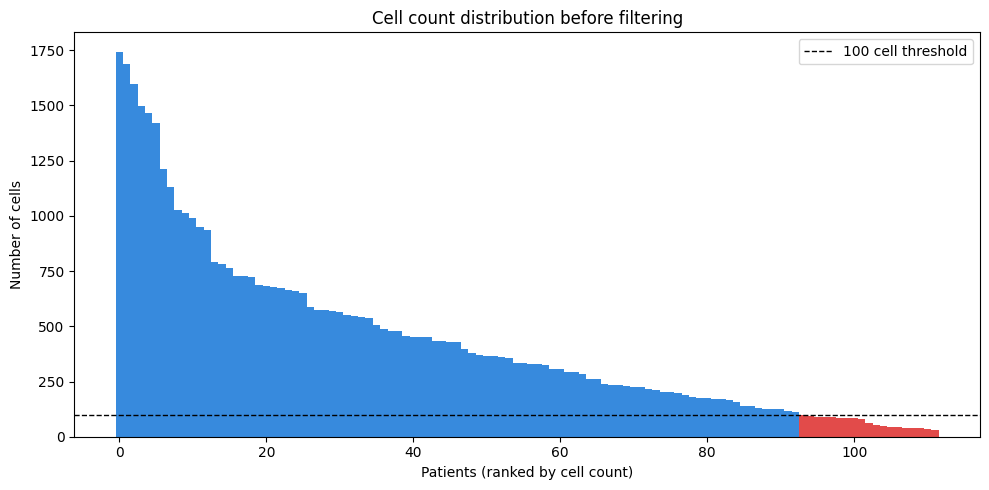


After filtering:
  Patients: 93
  Cells:    47495

Sanity check:
  dtype:       int64
  all integers: True
  sparsity:     0.96


In [2]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
adata = sc.read_h5ad('sample_data/Variant_Vax_obj.h5ad')
print("Before filtering:")
print(f"  Patients: {adata.obs['Participant'].nunique()}")
print(f"  Cells:    {adata.n_obs}")

# ── 2. Plot distribution before filtering ────────────────────────────────────
cell_counts = adata.obs["Participant"].value_counts()
colors = ["#E24B4A" if c < 100 else "#378ADD" for c in cell_counts]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(cell_counts)), cell_counts.values, color=colors, width=1.0)
ax.axhline(y=100, color="black", linestyle="--", linewidth=1, label="100 cell threshold")
ax.set_xlabel("Patients (ranked by cell count)")
ax.set_ylabel("Number of cells")
ax.set_title("Cell count distribution before filtering")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. Filter patients with fewer than 100 cells ─────────────────────────────
keep = cell_counts[cell_counts >= 100].index
adata = adata[adata.obs["Participant"].isin(keep)].copy()

print("\nAfter filtering:")
print(f"  Patients: {adata.obs['Participant'].nunique()}")
print(f"  Cells:    {adata.n_obs}")

# ── 4. Verify raw counts still intact ────────────────────────────────────────
sample = adata.X[:500].toarray()
print(f"\nSanity check:")
print(f"  dtype:       {adata.X.dtype}")
print(f"  all integers: {(sample == sample.astype(int)).all()}")
print(f"  sparsity:     {(sample == 0).mean():.2f}")

In [3]:
# ── 1. Select highly variable genes ──────────────────────────────────────────
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat_v3",
    layer=None
)

print(f"Highly variable genes: {adata.var['highly_variable'].sum()}")

Highly variable genes: 3000


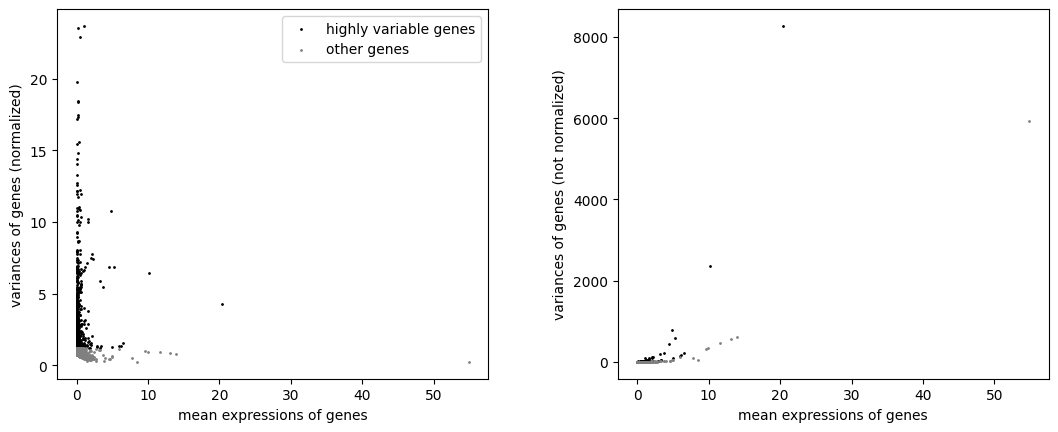

In [4]:
adata.var['highly_variable'].sum()  # confirms the count
sc.pl.highly_variable_genes(adata)  # plots the selection

In [5]:
hvgs = adata.var_names[adata.var['highly_variable']]
print(hvgs[hvgs.str.startswith('MT-')])   # mitochondrial
print(hvgs[hvgs.str.startswith('RPS')])   # ribosomal small
print(hvgs[hvgs.str.startswith('RPL')])   # ribosomal large

Index(['MT-ATP8', 'MT-CO3', 'MT-ND1', 'MT-ND3', 'MT-ND4L', 'MT-ND5', 'MT-ND6'], dtype='object', name='gene')
Index(['RPS27'], dtype='object', name='gene')
Index(['RPL41'], dtype='object', name='gene')


In [6]:
# ── 2. Remove mitochondrial and ribosomal genes ───────────────────────────────
mito_ribo = adata.var_names[
    adata.var_names.str.startswith(('MT-', 'RPS', 'RPL'))
]
adata.var['highly_variable'] = (
    adata.var['highly_variable'] & ~adata.var_names.isin(mito_ribo)
)
print(f"HVGs after exclusion: {adata.var['highly_variable'].sum()}")

HVGs after exclusion: 2991


In [7]:
print(f"Cells: {adata.n_obs} | HVGs: {adata.var['highly_variable'].sum()}")

Cells: 47495 | HVGs: 2991


In [9]:
# ── Pre-Flight Input Size Verification ────────────────────────────────────────

# Compute sizes directly using the HVG boolean mask from Chunk 5
active_hvg_count = adata.var['highly_variable'].sum()
active_participant_count = adata.obs["Participant"].nunique()
active_cell_count = adata.n_obs

print("🛑 PRE-FLIGHT TRAINING CHECK")
print("=" * 45)
print(f"🧬 Input Layer Size (Genes):     {active_hvg_count}")
print(f"👥 Batch Key Categories (Patients): {active_participant_count}")
print(f"🧫 Dataset Matrix Shape:         ({active_cell_count}, {active_hvg_count})")
print("=" * 45)

# Safety Check warnings
if active_hvg_count > 5000:
    print("⚠️ WARNING: Gene count is quite high. Training might be sluggish.")
if active_cell_count < 1000:
    print("⚠️ WARNING: Small cell count. Ensure early stopping patience isn't too aggressive.")
else:
    print("✅ Dimensions look solid. Ready to initialize model.")

🛑 PRE-FLIGHT TRAINING CHECK
🧬 Input Layer Size (Genes):     2991
👥 Batch Key Categories (Patients): 93
🧫 Dataset Matrix Shape:         (47495, 2991)
✅ Dimensions look solid. Ready to initialize model.


# Training on 3000 HVG

Genes: 2991 | Cells: 47495


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


Done — latent representation stored in adata_hvg.obsm['X_scVI']


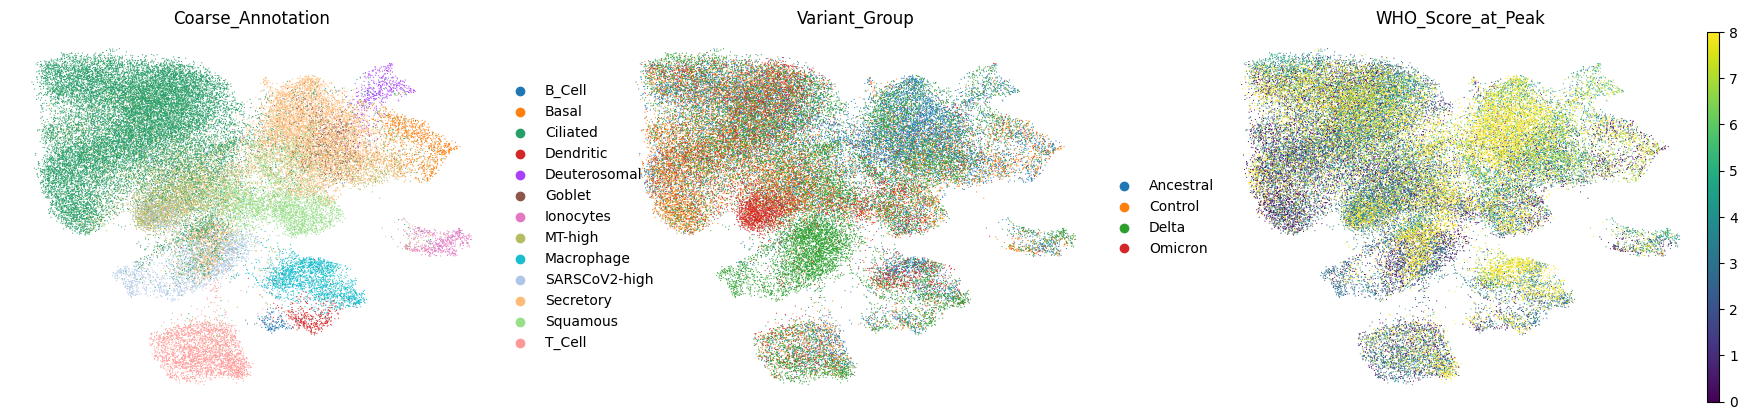

In [10]:
# ── RETRAIN scVI ON HVG ONLY ──────────────────────────────────────────────────

# ── 1. Subset to HVGs ─────────────────────────────────────────────────────────
adata_hvg = adata[:, adata.var['highly_variable']].copy()
print(f"Genes: {adata_hvg.n_vars} | Cells: {adata_hvg.n_obs}")

# ── 2. Setup anndata ──────────────────────────────────────────────────────────
scvi.model.SCVI.setup_anndata(
    adata_hvg,
    batch_key="Participant"
)

# ── 3. Build model ────────────────────────────────────────────────────────────
model_hvg = scvi.model.SCVI(
    adata_hvg,
    n_latent=20,
    n_layers=2,
    n_hidden=128,
    gene_likelihood="nb"
)

# ── 4. Train ──────────────────────────────────────────────────────────────────
model_hvg.train(
    max_epochs=400,
    early_stopping=True,
    early_stopping_patience=20
)

# ── 5. Store latent representation and recompute UMAP ─────────────────────────
adata_hvg.obsm["X_scVI"] = model_hvg.get_latent_representation()

sc.pp.neighbors(adata_hvg, use_rep="X_scVI")
sc.tl.umap(adata_hvg)
sc.tl.leiden(adata_hvg, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)

print("Done — latent representation stored in adata_hvg.obsm['X_scVI']")

# ── 6. Quick sanity plot ──────────────────────────────────────────────────────
sc.pl.umap(adata_hvg, color=["Coarse_Annotation", "Variant_Group", "WHO_Score_at_Peak"],
           frameon=False, ncols=3)

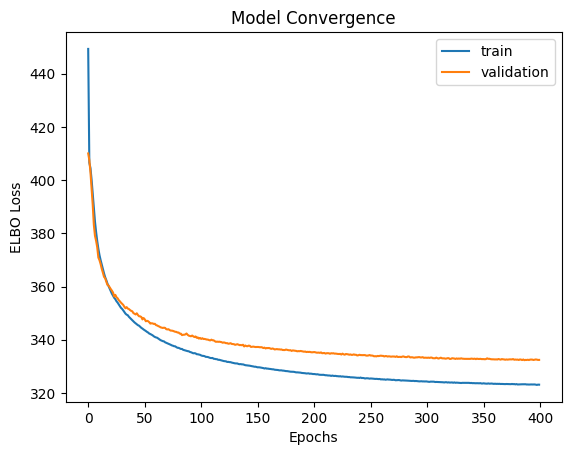

In [11]:
# Run this right after training to see if the loss curve flattened out
plt.plot(model_hvg.history["elbo_train"], label="train")
plt.plot(model_hvg.history["elbo_validation"], label="validation")
plt.title("Model Convergence")
plt.xlabel("Epochs")
plt.ylabel("ELBO Loss")
plt.legend()
plt.show()

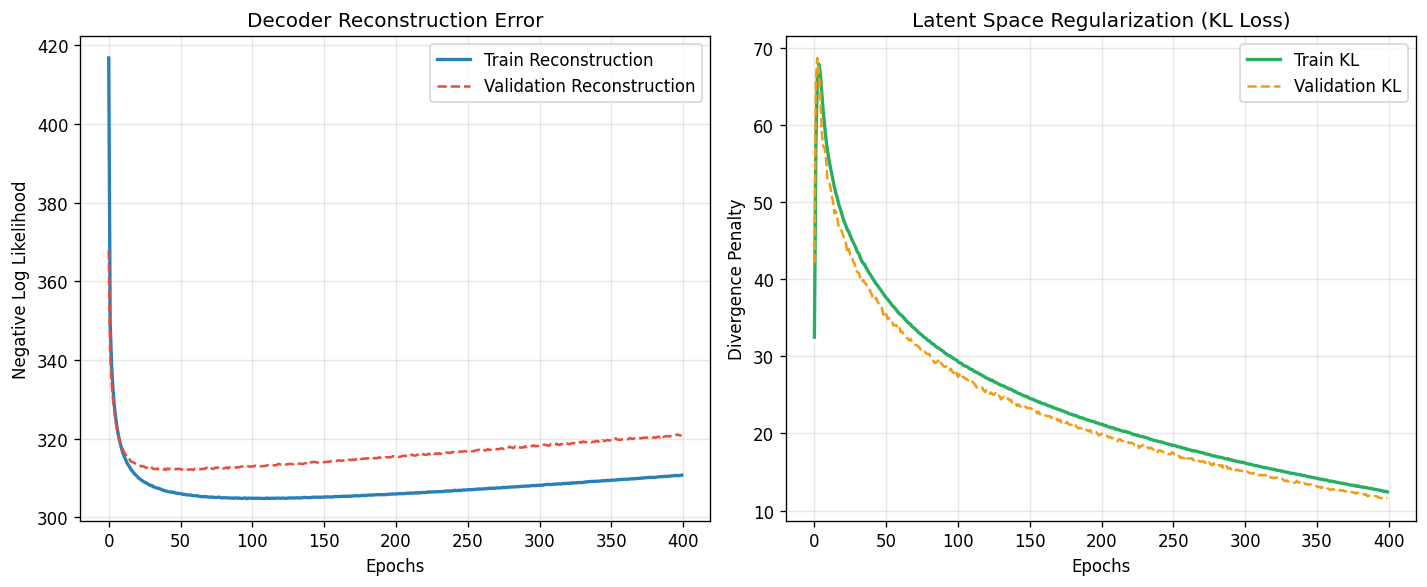

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract full history
history = model_hvg.history

# Format into a clean DataFrame
train_loss = pd.DataFrame({
    'Reconstruction': history['reconstruction_loss_train']['reconstruction_loss_train'],
    'KL_Divergence': history['kl_local_train']['kl_local_train']
})
val_loss = pd.DataFrame({
    'Reconstruction': history['reconstruction_loss_validation']['reconstruction_loss_validation'],
    'KL_Divergence': history['kl_local_validation']['kl_local_validation']
})

# Plotting the Breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

# 1. Reconstruction Loss Plot
axes[0].plot(train_loss['Reconstruction'], label='Train Reconstruction', color='#2980b9', lw=2)
axes[0].plot(val_loss['Reconstruction'], label='Validation Reconstruction', color='#e74c3c', lw=1.5, linestyle='--')
axes[0].set_title('Decoder Reconstruction Error')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Negative Log Likelihood')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. KL Divergence Plot
axes[1].plot(train_loss['KL_Divergence'], label='Train KL', color='#27ae60', lw=2)
axes[1].plot(val_loss['KL_Divergence'], label='Validation KL', color='#f39c12', lw=1.5, linestyle='--')
axes[1].set_title('Latent Space Regularization (KL Loss)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Divergence Penalty')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scVI_loss_components.png')
plt.show()

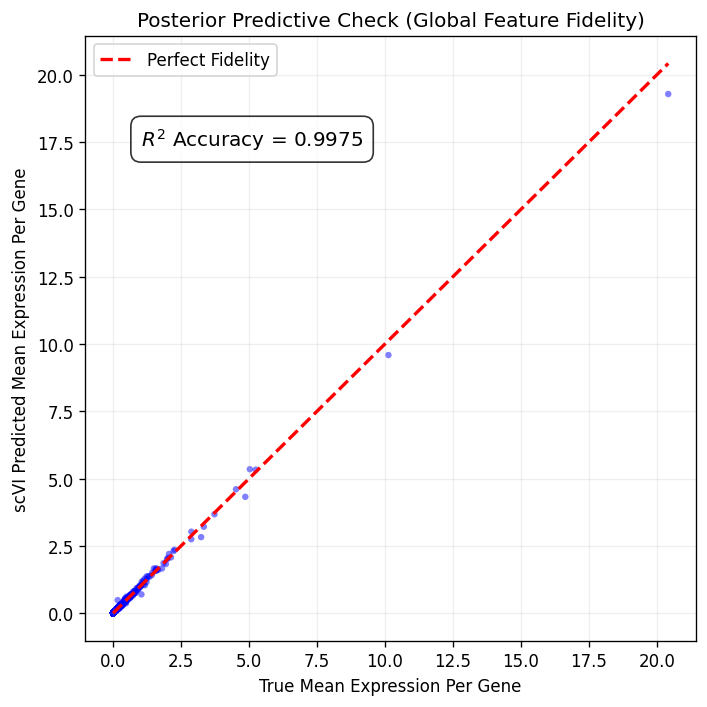

In [32]:
import numpy as np
import scipy.sparse

# 1. Sample reconstructed denoised data
reconstructed_counts = model_hvg.posterior_predictive_sample(n_samples=1)

# Clean handling for true data matrix format
if scipy.sparse.issparse(adata_hvg.X):
    true_means = np.asarray(adata_hvg.X.mean(axis=0)).flatten()
else:
    true_means = adata_hvg.X.mean(axis=0)

# Clean handling for scVI's generated sparse array format
if hasattr(reconstructed_counts, 'todense'):
    # Fix for the sparse library runtime error
    pred_means = np.asarray(reconstructed_counts.todense().mean(axis=0)).flatten()
elif scipy.sparse.issparse(reconstructed_counts):
    pred_means = np.asarray(reconstructed_counts.mean(axis=0)).flatten()
else:
    pred_means = reconstructed_counts.mean(axis=0)

# 2. Compute the Pearson R^2 performance score
correlation = np.corrcoef(true_means, pred_means)[0, 1]
r_squared = correlation ** 2

# 3. Plot the Empirical vs Reconstructed Accuracies
plt.figure(figsize=(6, 6), dpi=120)
plt.scatter(true_means, pred_means, alpha=0.5, color='blue', edgecolors='none', s=15)

# Perfect reconstruction baseline line
max_val = max(true_means.max(), pred_means.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Perfect Fidelity')

plt.title('Posterior Predictive Check (Global Feature Fidelity)')
plt.xlabel('True Mean Expression Per Gene')
plt.ylabel('scVI Predicted Mean Expression Per Gene')
plt.text(max_val*0.05, max_val*0.85, f'$R^2$ Accuracy = {r_squared:.4f}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

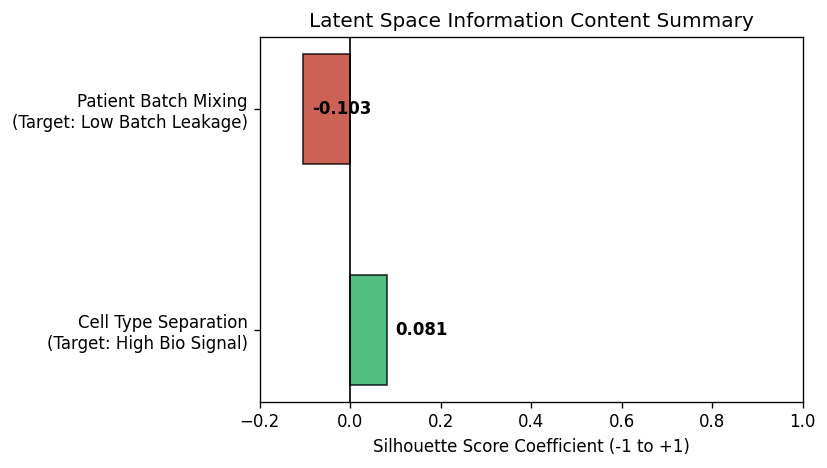

In [30]:
from sklearn.metrics import silhouette_score

# Sample a balanced subset of rows to prevent memory exhaustion on massive matrices
sample_indices = np.random.choice(len(latent_df), size=min(5000, len(latent_df)), replace=False)
latent_sample = latent_df.iloc[sample_indices][[f'scVI_{i+1}' for i in range(20)]]
metadata_sample = latent_df.iloc[sample_indices]

# Calculate numerical silhouette metrics
bio_silhouette = silhouette_score(latent_sample, metadata_sample['cell_type'])
batch_silhouette = silhouette_score(latent_sample, metadata_sample['Participant'])

# Plotting the Performance Comparison Bar
plt.figure(figsize=(7, 4), dpi=120)
metrics = ['Cell Type Separation\n(Target: High Bio Signal)', 'Patient Batch Mixing\n(Target: Low Batch Leakage)']
scores = [bio_silhouette, batch_silhouette]
colors = ['#27ae60', '#c0392b']

bars = plt.barh(metrics, scores, color=colors, height=0.5, edgecolor='black', alpha=0.8)
plt.xlim(-0.2, 1.0)
plt.axvline(x=0, color='black', lw=1, linestyle='-')

# Annotate values on top of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', ha='left', fontweight='bold', fontsize=10)

plt.title('Latent Space Information Content Summary')
plt.xlabel('Silhouette Score Coefficient (-1 to +1)')
plt.tight_layout()
plt.savefig('scVI_latent_separation_metrics.png')
plt.show()

In [33]:
print(model_hvg.is_trained)

True


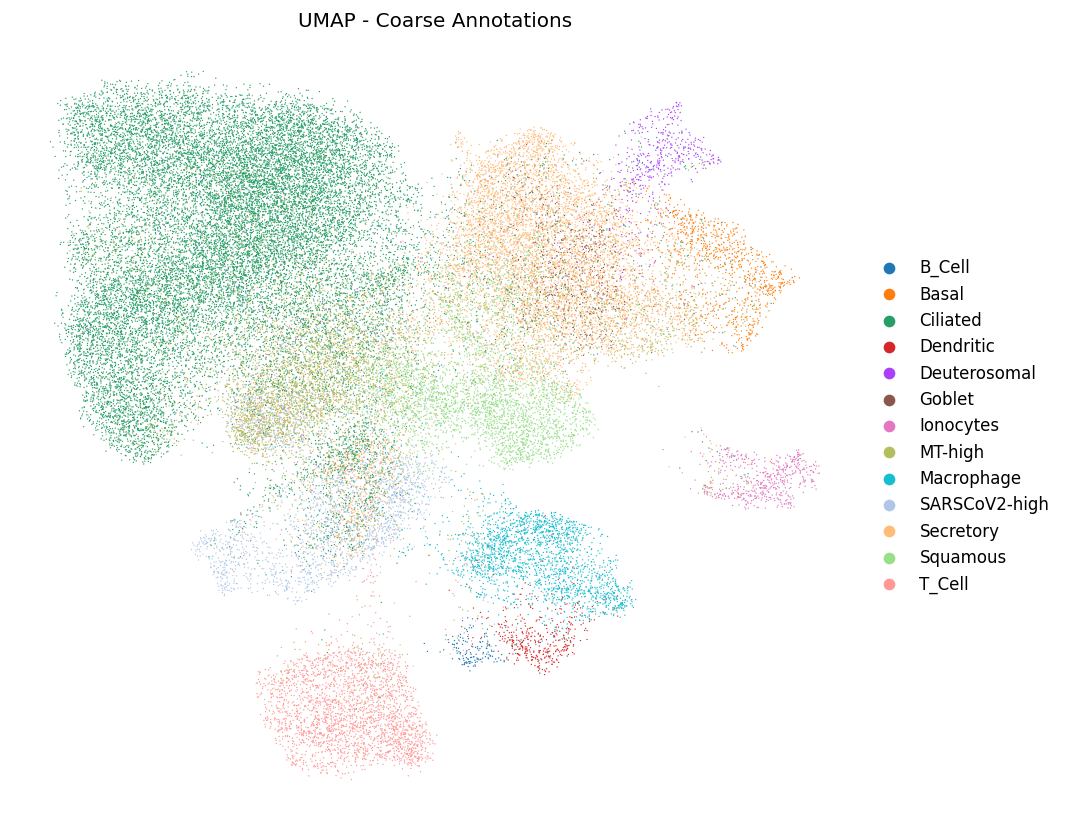

In [13]:
with plt.rc_context({"figure.figsize": (9, 7), "figure.dpi": 120}):
    sc.pl.umap(
        adata_hvg,
        color="Coarse_Annotation",
        legend_loc="right margin",      # Moves labels to a clean list on the right
        frameon=False,
        title="UMAP - Coarse Annotations",
        show=False
    )
    plt.tight_layout()
    plt.show()

In [16]:
# ── Clean Latent Space Extraction (Run BEFORE subsetting) ────────────────────

latent_df = pd.DataFrame(
    adata_hvg.obsm["X_scVI"],
    index=adata_hvg.obs_names,
    columns=[f"scVI_{i+1}" for i in range(20)]
)

# Pull available metadata safely
latent_df['cell_type']          = adata_hvg.obs['Coarse_Annotation']
latent_df['WHO_score']          = adata_hvg.obs['WHO_Score_at_Peak']
latent_df['Participant']        = adata_hvg.obs['Participant']
latent_df['Variant_Group']      = adata_hvg.obs['Variant_Group']
latent_df['Vaccination_Status'] = adata_hvg.obs['Vaccination_Status']
# Adding PCR status just in case you want to filter by it later
latent_df['PCR_Status']         = adata_hvg.obs['SARSCoV2_PCR_Status']

print(f"✅ Success! Full Matrix Shape: {latent_df.shape}")
print(latent_df.head())

# Save the complete, uncompromised latent space
latent_df.to_parquet('scvi_latent_representation_full.parquet')
# Use this if you prefer a standard CSV file
latent_df.to_csv('scvi_latent_representation_full.csv')

✅ Success! Full Matrix Shape: (47495, 26)
                                         scVI_1    scVI_2    scVI_3    scVI_4  \
Ancestral_A_COVID19_01_CAACGCGGGTTG-1  0.626717  0.112229  0.200172  0.361438   
Ancestral_A_COVID19_01_CAGACCTTCTGT-1  0.578153 -1.225292  0.162785 -0.294023   
Ancestral_A_COVID19_01_CTAGCCAGACCA-1  0.200283  0.111019  0.485231  0.714581   
Ancestral_A_COVID19_01_GGGTACTTGGGA-1 -0.171051  0.443328 -0.588194  0.140307   
Ancestral_A_COVID19_01_GAAAGCAGTGTG-1 -0.681070  0.018994  0.923945  0.249911   

                                         scVI_5    scVI_6    scVI_7    scVI_8  \
Ancestral_A_COVID19_01_CAACGCGGGTTG-1 -1.328863  0.060328 -0.620050  0.629106   
Ancestral_A_COVID19_01_CAGACCTTCTGT-1 -0.148602 -0.747617 -1.299047  0.356626   
Ancestral_A_COVID19_01_CTAGCCAGACCA-1 -0.121322  0.349625 -0.858654  0.291683   
Ancestral_A_COVID19_01_GGGTACTTGGGA-1  0.115547  0.191355  0.591725  0.129729   
Ancestral_A_COVID19_01_GAAAGCAGTGTG-1 -0.894800 -0.138508  0.62084

## Running DE

In [17]:
# Rebuild severity column and subsets on adata_hvg
adata_hvg.obs['WHO_severity'] = np.where(
    adata_hvg.obs['WHO_Score_at_Peak'].isin([1,2,3]), 'mild',
    np.where(adata_hvg.obs['WHO_Score_at_Peak'].isin([5,6,7,8]), 'severe', 'exclude')
)

adata_hvg_pos = adata_hvg[adata_hvg.obs['SARSCoV2_PCR_Status'] == 'positive'].copy()
subset_hvg = adata_hvg_pos[adata_hvg_pos.obs['WHO_severity'] != 'exclude']

print(f"Cells for DE: {subset_hvg.n_obs}")
print(subset_hvg.obs['WHO_severity'].value_counts())

Cells for DE: 28310
WHO_severity
severe    21268
mild       7042
Name: count, dtype: int64


In [18]:
cell_types_to_run = ['Ciliated', 'Secretory', 'Squamous', 'Basal',
                     'SARSCoV2-high', 'Ionocytes', 'MT-high',
                     'Macrophage', 'Dendritic', 'T_Cell']

de_results_hvg = {}

for ct in cell_types_to_run:
    print(f"Running DE for {ct}...")
    adata_ct = subset_hvg[subset_hvg.obs['Coarse_Annotation'] == ct].copy()

    de = model_hvg.differential_expression(
        adata=adata_ct,
        groupby='WHO_severity',
        group1='severe',
        group2='mild'
    )

    # Calculate LFC
    de['lfc'] = np.log2(de['scale1'] + 1e-10) - np.log2(de['scale2'] + 1e-10)
    de_results_hvg[ct] = de

    # Summary using proba_m1
    up = (de['proba_m1'] > 0.95).sum()
    down = (de['proba_m1'] < 0.05).sum()
    print(f"  → {up} up in severe | {down} down in severe\n")

print("All done!")

Running DE for Ciliated...
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 12 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

  → 0 up in severe | 0 down in severe

Running DE for Secretory...
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 23 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


...

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

  → 14 up in severe | 1 down in severe

Running DE for T_Cell...
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 59 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

  → 0 up in severe | 0 down in severe

All done!


In [19]:

def is_named_gene(gene):
    return not re.match(r'^(AC|AL|AP|AF|AJ|BX|CR|CT|CU|FP|HG|LI|LN|MK)\d+', gene)

for ct in ['Macrophage', 'Dendritic']:
    de = de_results_hvg[ct]

    up = de[de['proba_m1'] > 0.95]
    down = de[de['proba_m1'] < 0.05]

    up_named = up[up.index.map(is_named_gene)].index.tolist()
    down_named = down[down.index.map(is_named_gene)].index.tolist()

    print(f"\n{ct} up in severe (named): {up_named}")
    print(f"{ct} down in severe (named): {down_named}")


Macrophage up in severe (named): ['PKP1', 'AMPH', 'MUC21', 'VEGFA', 'HIST1H1C', 'TTR', 'LUCAT1']
Macrophage down in severe (named): ['GJA3']

Dendritic up in severe (named): ['BEST1', 'TMPRSS2', 'LYPD2', 'SERPINB11', 'SPRR1B', 'SERPINB3', 'GPCPD1', 'GNE', 'KRT13', 'KRT7', 'SCEL', 'GPRC5A', 'PRSS22', 'SPINK7']
Dendritic down in severe (named): ['OTOF']


## Pathway Analysis

In [20]:

gene_sets = ['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022']

de_gene_lists = {
    'Macrophage_up': ['LINC01291', 'CEACAM7', 'MIR4435-2HG', 'LUCAT1', 'ABCA1',
                      'TYRO3', 'SPRR2D', 'HIST1H2AC', 'TRPM5', 'ADGRE3', 'CAPN14', 'TMPRSS11F'],
    'Macrophage_down': ['NTRK1', 'GJA3'],
    'Dendritic_up': ['SERPINB13', 'BEST1', 'MMACHC', 'GPCPD1'],
    'Dendritic_down': []
}

pathway_results = {}

for name, genes in de_gene_lists.items():
    if len(genes) < 3:
        print(f"Skipping {name} — too few genes ({len(genes)})")
        continue

    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=gene_sets,
        organism='human',
        outdir=None
    )
    pathway_results[name] = enr.results

    sig = enr.results[enr.results['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')
    print(f"\n=== {name} — significant pathways ===")
    if len(sig) == 0:
        print("  No significant pathways found")
    else:
        print(sig[['Gene_set', 'Term', 'Adjusted P-value', 'Genes']].head(10).to_string())


=== Macrophage_up — significant pathways ===
           Gene_set                          Term  Adjusted P-value  Genes
45  KEGG_2021_Human  Fat digestion and absorption          0.049331  ABCA1
46  KEGG_2021_Human              ABC transporters          0.049331  ABCA1
47  KEGG_2021_Human        Cholesterol metabolism          0.049331  ABCA1
Skipping Macrophage_down — too few genes (2)

=== Dendritic_up — significant pathways ===
                      Gene_set                                                                                               Term  Adjusted P-value      Genes
28               Reactome_2022                                                                    Hydrolysis Of LPC R-HSA-1483115          0.012592     GPCPD1
27               Reactome_2022  RUNX1 Regulates Transcription Of Genes Involved In Differentiation Of Keratinocytes R-HSA-8939242          0.012592  SERPINB13
26               Reactome_2022                                                         

### Relaxing threshold

In [21]:
for ct in ['Macrophage', 'Dendritic']:
    de = de_results_hvg[ct]
    up = de[de['proba_m1'] > 0.9]
    down = de[de['proba_m1'] < 0.1]
    up_named = up[up.index.map(is_named_gene)].index.tolist()
    down_named = down[down.index.map(is_named_gene)].index.tolist()
    print(f"\n{ct} up (named): {len(up_named)} genes: {up_named}")
    print(f"{ct} down (named): {len(down_named)} genes: {down_named}")


Macrophage up (named): 86 genes: ['PKP1', 'AMPH', 'MUC21', 'VEGFA', 'HIST1H1C', 'TTR', 'LUCAT1', 'MIR4435-2HG', 'SPRR2A', 'TRPA1', 'ABCA1', 'ADGRE3', 'GPRC5A', 'BEST1', 'KRT13', 'PRSS22', 'FAM166A', 'CAPN14', 'MCEMP1', 'GPCPD1', 'STEAP4', 'SPNS2', 'PRSS8', 'TMPRSS11E', 'TMPRSS11F', 'PRTG', 'CLDN17', 'PITX1', 'SLC25A37', 'GCNT3', 'TMPRSS11B', 'ITGB8', 'ARFIP2', 'HIST1H2AC', 'CALB1', 'IL1R2', 'KLK5', 'HEPHL1', 'TMPRSS2', 'FAM180A', 'CXCL6', 'SPRR2D', 'MUC22', 'CEACAM5', 'IL36RN', 'MEIOC', 'PPBP', 'TCN1', 'SCEL', 'VCAN', 'DNAJB7', 'TMEM40', 'CPB1', 'PDZK1IP1', 'CD55', 'TM4SF1', 'MTRNR2L4', 'MUC7', 'KLK12', 'KLK7', 'DSC3', 'LMF1-AS1', 'RNASE7', 'SPRR1A', 'Z82217.1', 'FSIP2', 'DEFA3', 'MSMB', 'ALOX12B', 'KSR2', 'S100P', 'ITGA2', 'MS4A2', 'GDF11', 'TULP2', 'PLAT', 'A2ML1', 'DOCK6', 'RNF223', 'LINC00520', 'ONECUT3', 'TRIM72', 'HCG22', 'PTHLH', 'CELF5', 'SAA1']
Macrophage down (named): 12 genes: ['BIRC7', 'ARSI', 'TPBGL', 'PLEKHO1', 'HCFC1-AS1', 'LGI2', 'CD209', 'TRBV18', 'ST3GAL5', 'ESPL1', 

## Extracting gene set
### Only Macrophages & Dendritic (overvej i din model)

In [23]:
# ── Create a Clean, Unique List of DE Genes ───────────────────────────────────

de_genes_set = set()

for ct in ['Macrophage', 'Dendritic']:
    de = de_results_hvg[ct]

    # Filter using your relaxed thresholds
    up = de[de['proba_m1'] > 0.9]
    down = de[de['proba_m1'] < 0.1]

    # Filter for named genes and grab the indices
    up_named = up[up.index.map(is_named_gene)].index.tolist()
    down_named = down[down.index.map(is_named_gene)].index.tolist()

    # Add them to our master set
    de_genes_set.update(up_named)
    de_genes_set.update(down_named)

# Convert back to a sorted list
final_de_gene_list = sorted(list(de_genes_set))

print("🧬 MASTER DE GENE LIST FOR ML")
print("=" * 45)
print(f"Total Unique Predictive Genes found: {len(final_de_gene_list)}")
print(f"Genes: {final_de_gene_list}")
print("=" * 45)

🧬 MASTER DE GENE LIST FOR ML
Total Unique Predictive Genes found: 225
Genes: ['A2ML1', 'ABCA1', 'ADD2', 'ADGRE3', 'ADIRF', 'AGR2', 'AKR1C1', 'ALOX12B', 'AMPH', 'ANKRD36', 'ANKRD36B', 'ANKRD36C', 'AQP5', 'ARFIP2', 'ARSI', 'ASPM', 'ATP2B1', 'ATP6V1C2', 'BEST1', 'BIRC7', 'BRINP1', 'CALB1', 'CAPN14', 'CAPN8', 'CCNG2', 'CD209', 'CD55', 'CDSN', 'CEACAM5', 'CEACAM6', 'CEACAM7', 'CEL', 'CELF5', 'CGA', 'CLCA4', 'CLDN17', 'CLMP', 'CNFN', 'CPA3', 'CPB1', 'CST6', 'CXCL10', 'CXCL6', 'CXCL9', 'CYP2F1', 'DEFA3', 'DKK1', 'DNAJB7', 'DOCK6', 'DSC3', 'DST', 'ESPL1', 'F3', 'FAM129B', 'FAM166A', 'FAM180A', 'FAM3D', 'FAM83D', 'FFAR2', 'FSCN3', 'FSIP2', 'FTL', 'GABRP', 'GALNT5', 'GCNT3', 'GDF11', 'GJA3', 'GNE', 'GPCPD1', 'GPR88', 'GPRC5A', 'GPX2', 'GRPEL2', 'GSTM5', 'H1F0', 'HBA2', 'HBD', 'HCFC1-AS1', 'HCG22', 'HEPHL1', 'HIST1H1C', 'HIST1H2AC', 'HOXA4', 'HPGD', 'HSD11B2', 'HSPB1', 'IFNB1', 'IFNL2', 'IGLVI-70', 'IL17A', 'IL1R2', 'IL1RL1', 'IL36A', 'IL36RN', 'ITGA2', 'ITGB8', 'KATNBL1', 'KCTD19', 'KLK12', 'KLK

In [24]:
# ── Find and Display Overlapping DE Genes ─────────────────────────────────────

# 1. Gather all unique genes for Macrophages
mac_genes = set()
de_mac = de_results_hvg['Macrophage']
mac_genes.update(de_mac[de_mac['proba_m1'] > 0.9].index[de_mac[de_mac['proba_m1'] > 0.9].index.map(is_named_gene)].tolist())
mac_genes.update(de_mac[de_mac['proba_m1'] < 0.1].index[de_mac[de_mac['proba_m1'] < 0.1].index.map(is_named_gene)].tolist())

# 2. Gather all unique genes for Dendritic cells
dc_genes = set()
de_dc = de_results_hvg['Dendritic']
dc_genes.update(de_dc[de_dc['proba_m1'] > 0.9].index[de_dc[de_dc['proba_m1'] > 0.9].index.map(is_named_gene)].tolist())
dc_genes.update(de_dc[de_dc['proba_m1'] < 0.1].index[de_dc[de_dc['proba_m1'] < 0.1].index.map(is_named_gene)].tolist())

# 3. Calculate the intersection (the overlap)
overlapping_genes = sorted(list(mac_genes & dc_genes))

print("🤝 MYELOID OVERLAPPING DE GENES")
print("=" * 55)
print(f"Total Macrophage Genes:       {len(mac_genes)}")
print(f"Total Dendritic Cell Genes:   {len(dc_genes)}")
print(f"Shared Overlapping Genes:     {len(overlapping_genes)} (The mathematical difference!)")
print("=" * 55)
print(f"Overlapping Gene List:\n{overlapping_genes}")
print("=" * 55)

🤝 MYELOID OVERLAPPING DE GENES
Total Macrophage Genes:       98
Total Dendritic Cell Genes:   163
Shared Overlapping Genes:     36 (The mathematical difference!)
Overlapping Gene List:
['ADGRE3', 'ARFIP2', 'BEST1', 'CALB1', 'CAPN14', 'CEACAM5', 'DEFA3', 'DSC3', 'FAM166A', 'GCNT3', 'GPCPD1', 'GPRC5A', 'HIST1H1C', 'KLK5', 'KRT13', 'MEIOC', 'MSMB', 'MUC21', 'MUC22', 'MUC7', 'PDZK1IP1', 'PITX1', 'PKP1', 'PLAT', 'PRSS22', 'PRSS8', 'S100P', 'SCEL', 'SPNS2', 'SPRR1A', 'SPRR2A', 'SPRR2D', 'STEAP4', 'TM4SF1', 'TMPRSS2', 'TTR']


In [26]:
# ── Build the Gene-Based ML Matrix ───────────────────────────────────────────

# 1. Extract the expression matrix for just our target genes
# We convert it to an array in case your matrix is stored as a sparse matrix
gene_expressions = adata_hvg[:, final_de_gene_list].X.toarray()

# 2. Turn it into a beautifully labeled DataFrame
gene_df = pd.DataFrame(
    gene_expressions,
    index=adata_hvg.obs_names,
    columns=final_de_gene_list
)

# 3. Attach the exact same metadata alignment columns as your latent file
gene_df['cell_type']          = adata_hvg.obs['Coarse_Annotation']
gene_df['WHO_score']          = adata_hvg.obs['WHO_Score_at_Peak']
gene_df['Participant']        = adata_hvg.obs['Participant']
gene_df['Variant_Group']      = adata_hvg.obs['Variant_Group']
gene_df['Vaccination_Status'] = adata_hvg.obs['Vaccination_Status']

print(f"✅ Success! Gene ML Matrix Shape: {gene_df.shape}")
print(gene_df.head())

# 4. Save it safely to your disk
gene_df.to_parquet('de_genes_expression_matrix.parquet')
gene_df.to_csv('de_genes_expression_matrix.csv')

✅ Success! Gene ML Matrix Shape: (47495, 230)
                                       A2ML1  ABCA1  ADD2  ADGRE3  ADIRF  \
Ancestral_A_COVID19_01_CAACGCGGGTTG-1      0      0     0       0      0   
Ancestral_A_COVID19_01_CAGACCTTCTGT-1      0      0     0       0      0   
Ancestral_A_COVID19_01_CTAGCCAGACCA-1      0      0     0       0      0   
Ancestral_A_COVID19_01_GGGTACTTGGGA-1      0      0     0       0      0   
Ancestral_A_COVID19_01_GAAAGCAGTGTG-1      0      0     0       0      0   

                                       AGR2  AKR1C1  ALOX12B  AMPH  ANKRD36  \
Ancestral_A_COVID19_01_CAACGCGGGTTG-1     0       0        0     0        0   
Ancestral_A_COVID19_01_CAGACCTTCTGT-1     0       0        0     0        1   
Ancestral_A_COVID19_01_CTAGCCAGACCA-1     4       0        0     0        0   
Ancestral_A_COVID19_01_GGGTACTTGGGA-1     5       0        0     0        0   
Ancestral_A_COVID19_01_GAAAGCAGTGTG-1     0       0        0     0        0   

                      

## Pathway analysis again

In [27]:

gene_sets = ['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022']

de_gene_lists_relaxed = {
    'Macrophage_up': ['LINC01291', 'CEACAM7', 'MIR4435-2HG', 'LUCAT1', 'ABCA1', 'TYRO3', 'SPRR2D', 'HIST1H2AC', 'TRPM5', 'ADGRE3', 'CAPN14', 'TMPRSS11F', 'GCNT3', 'AMPH', 'KLK10', 'MMACHC', 'SPRR1A', 'AMT', 'ITGB8', 'HIST1H1C', 'TAC1', 'SLC25A37', 'CLCA4', 'TRPA1', 'CXCL6', 'FLG', 'DNAJB7', 'AKR1B10', 'HEPHL1', 'DSC3', 'TGFB2', 'VEGFA', 'MCEMP1', 'TMPRSS2', 'CCDC144A', 'PCAT7', 'TLR2', 'NUP210L', 'MCF2L2', 'CD55', 'SLITRK5', 'RELN', 'KRT17', 'TCN1', 'ZIC5', 'BEST1', 'IL1R2', 'WASF3-AS1', 'TCIM', 'CLEC5A', 'RETN', 'VCAN', 'KLK7', 'KRT6A', 'DSG3', 'GPCPD1', 'TMPRSS11E', 'LINC00452', 'MCPH1-AS1', 'MYPN', 'CPB1', 'HIST1H1B', 'TMPRSS11D', 'C1orf167', 'S100P', 'VMP1', 'TMEM40', 'SPRR1B', 'SMIM9', 'WFDC12', 'PPBP', 'SERPINB13', 'TMPRSS11A', 'MSMB', 'CEACAM5', 'EGOT', 'TM4SF1', 'MUC3A', 'MYH11', 'KRT13', 'STEAP4', 'PSCA', 'POU6F2', 'LINC00520', 'SLC26A8', 'AKR1C2', 'ADIPOQ', 'PRSS22', 'LY6D', 'KRT6B', 'TMEM132B', 'KSR2', 'COL17A1', 'PMP2', 'GPRC5A', 'NRXN2', 'UCA1', 'P4HA3', 'HBA2', 'HBD', 'SPRR2A', 'GDF7', 'CCL20', 'KIAA1614'],
    'Macrophage_down': ['C6orf15', 'IRF8', 'LGI2', 'TRBV18', 'PLEKHO1', 'CD209', 'GPR88', 'NTRK1', 'GJA3'],
    'Dendritic_up': ['SERPINB13', 'BEST1', 'MMACHC', 'GPCPD1', 'HIST1H1C', 'CST6', 'CEACAM7', 'TMPRSS2', 'HSPB1', 'SERPINB4', 'SPRR2D', 'CTSV', 'TM4SF1', 'LYPD2', 'SPRR1B', 'PSCA', 'SPRR1A', 'PI3', 'MUC21', 'SCEL', 'ZNF292', 'RNF39', 'ATP2B1', 'LAMA4', 'ATP6V1C2', 'TRPM5', 'ABCA1', 'PRSS22', 'DCHS2', 'F3', 'CDSN', 'AQP5', 'GALNT5', 'TMPRSS11F', 'SMIM9', 'S100A7', 'KRT7', 'TGFB2', 'VMO1', 'FAM129B', 'SGK1', 'KRT4', 'VMP1', 'P4HA3', 'ADIRF', 'GADD45A', 'KRT13', 'KRT6B', 'PTPN13', 'HPGD', 'CLCA4', 'PLS3', 'FTL', 'TMEM132D', 'RNF152', 'SULT1E1', 'CAPN14', 'CNFN', 'CXCL6', 'RNF223', 'TMPRSS11E', 'FLG', 'RGS21', 'SPRR2E', 'CEACAM6', 'MIR4435-2HG', 'COL1A2', 'GCNT3', 'TAC1', 'SLC5A3', 'S100A2', 'PTGES', 'MMP3', 'AGR2', 'KRT16', 'SLC6A14', 'TMEM132B', 'DST', 'H1F0', 'SPRR2A', 'GPRC5A', 'SPRR3', 'SOX4', 'S100A14', 'TCIM', 'ALDH1A3', 'TINAGL1', 'SLPI', 'SERPINB3', 'MSMB', 'HIST1H4C', 'TNN', 'SERPINB11', 'CPA4', 'CXCL5', 'SFN', 'RND3', 'TMSB4X', 'SDC1', 'TMPRSS11A', 'S100P', 'ITGA2', 'ITGB8', 'HBA2', 'LCN2', 'GNE', 'DEFB4A', 'AKR1B10', 'TCN1'],
    'Dendritic_down': ['IFNL2', 'MYT1L', 'SCARA5', 'RASD2', 'CXCL9', 'OTOF']
}

pathway_results_relaxed = {}

for name, genes in de_gene_lists_relaxed.items():
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=gene_sets,
        organism='human',
        outdir=None
    )
    pathway_results_relaxed[name] = enr.results

    sig = enr.results[enr.results['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')
    print(f"\n=== {name} — top 10 significant pathways ===")
    if len(sig) == 0:
        print("  No significant pathways found")
    else:
        print(sig[['Gene_set', 'Term', 'Adjusted P-value', 'Genes']].head(10).to_string())


=== Macrophage_up — top 10 significant pathways ===
            Gene_set                                                                              Term  Adjusted P-value                                                                                Genes
888    Reactome_2022                                                      Keratinization R-HSA-6805567          0.000002                    FLG;KRT17;KRT13;DSG3;SPRR2A;SPRR1A;KRT6B;SPRR1B;KRT6A;DSC3;SPRR2D
889    Reactome_2022                                     Formation Of Cornified Envelope R-HSA-6809371          0.000012                                            FLG;DSG3;SPRR2A;SPRR1A;SPRR1B;DSC3;SPRR2D
772  KEGG_2021_Human                                                              Rheumatoid arthritis          0.014474                                                         CXCL6;TGFB2;CCL20;TLR2;VEGFA
890    Reactome_2022                                            Neutrophil Degranulation R-HSA-6798695          0.043849   

EnrichrAPIError: Error sending gene list, status code: 429